# StateSpaceModels.jl

In [194]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `c:\Users\matheuscn.ELE.000\Documents\Diversos\MathNogMediumArticles\Articles`


In [195]:
Pkg.add("StateSpaceModels")
Pkg.add("DataFrames")
Pkg.add("CSV")
Pkg.add("Plots")

   Resolving package versions...
  No Changes to `C:\Users\matheuscn.ELE.000\Documents\Diversos\MathNogMediumArticles\Articles\Project.toml`
  No Changes to `C:\Users\matheuscn.ELE.000\Documents\Diversos\MathNogMediumArticles\Articles\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\matheuscn.ELE.000\Documents\Diversos\MathNogMediumArticles\Articles\Project.toml`
  No Changes to `C:\Users\matheuscn.ELE.000\Documents\Diversos\MathNogMediumArticles\Articles\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\matheuscn.ELE.000\Documents\Diversos\MathNogMediumArticles\Articles\Project.toml`
  No Changes to `C:\Users\matheuscn.ELE.000\Documents\Diversos\MathNogMediumArticles\Articles\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\matheuscn.ELE.000\Documents\Diversos\MathNogMediumArticles\Articles\Project.toml`
  No Changes to `C:\Users\matheuscn.ELE.000\Documents\Diversos\MathNogMediumArticles\Articles\Manifest.toml`


In [196]:
using StateSpaceModels, DataFrames, CSV, Plots

In [197]:
function plot_time_series(time_series::DataFrame, x_axis::String, y_axis::String,
                        title::String, x_label::String, y_label::String;
                        test_length::Int64 = 0)

    time_series_train = time_series[1:end - test_length, :]
    time_series_test = time_series[end - test_length + 1:end, :]
    plot(time_series[:, x_axis], time_series[:, y_axis], title = title, label = "", xlabel = x_label, ylabel = y_label)
    plot!(time_series_test[:, x_axis], time_series_test[:, y_axis], title = title, label = "Test", xlabel = x_label, ylabel = y_label)
end

function time_series_split(time_series::DataFrame, test_length::Int64)
    train_series = time_series[1:end - test_length, :]
    test_series = time_series[end - test_length + 1:end, :]

    return train_series, test_series
end

time_series_split (generic function with 1 method)

## Loading AirLinePassengers and RJ Temperature Datasets

In [198]:
rj_temp = CSV.File(StateSpaceModels.RJ_TEMPERATURE) |> DataFrame;
airline = CSV.File(StateSpaceModels.AIR_PASSENGERS) |> DataFrame;

airline.passengers = log.(Float64.(airline.passengers));

## Visual inspection of both time series

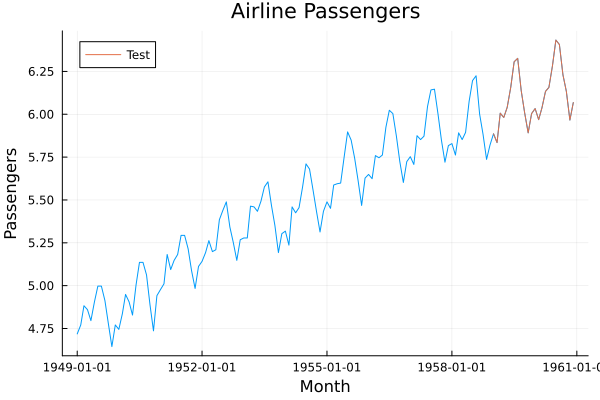

In [199]:
title = "Airline Passengers"
x_label = "Month"
y_label = "Passengers"
test_length_airline = 12*2
plot_time_series(airline, "month", "passengers", title, x_label, y_label; test_length = test_length_airline)

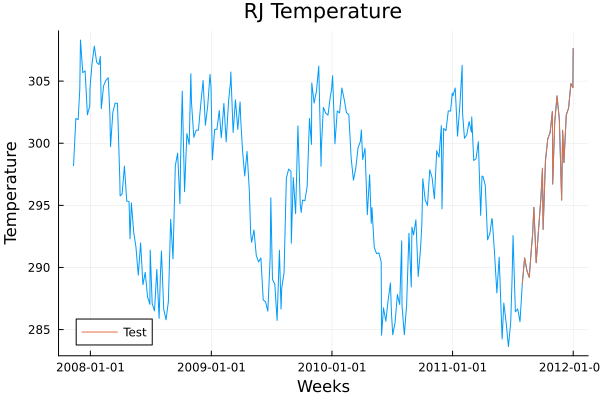

In [200]:
title = "RJ Temperature"
x_label = "Weeks"
y_label = "Temperature"
test_length_rj = 7*4
plot_time_series(rj_temp, "Timestamp", "Values", title, x_label, y_label; test_length = test_length_rj)

In [201]:
airline_train, airline_test = time_series_split(airline, test_length_airline);
rj_temp_train, rj_temp_test = time_series_split(rj_temp, test_length_rj);

## Specifying the models

In [218]:
ssm_airline = StateSpaceModels.UnobservedComponents(airline_train.passengers;
                                                    trend = "local linear trend",
                                                    seasonal = "stochastic 12",
                                                    cycle = "no");

ssm_rj = StateSpaceModels.UnobservedComponents(rj_temp_train.Values;
                                               trend = "local level",
                                               seasonal = "stochastic 12", # there is no reason for weekly seasonality
                                               cycle = "no");

## Fitting the models

In [219]:
StateSpaceModels.fit!(ssm_airline);
StateSpaceModels.fit!(ssm_rj);

┌ Warning: f_tol is deprecated. Use f_abstol or f_reltol instead. The provided value (1.0e-6) will be used as f_reltol.
└ @ Optim C:\Users\matheuscn.ELE.000\.julia\packages\Optim\7krni\src\types.jl:120
┌ Warning: f_tol is deprecated. Use f_abstol or f_reltol instead. The provided value (1.0e-6) will be used as f_reltol.
└ @ Optim C:\Users\matheuscn.ELE.000\.julia\packages\Optim\7krni\src\types.jl:120


In [220]:
printstyled("Airline Passengers Model Results\n", color = :green)
print_results(ssm_airline);
printstyled("RJ Temperature Model Results\n", color = :green)
print_results(ssm_rj);

Airline Passengers Model Results
                             Results                           
Model:                        UnobservedComponents
Number of observations:       120
Number of unknown parameters: 4
Log-likelihood:               190.4584
AIC:                          -372.9169
AICc:                         -372.5690
BIC:                          -361.7669
----------------------------------------------------------------------
Parameter             Estimate      Std.Error      z stat      p-value
sigma2_irregular        0.0001         0.0062      0.0227       0.0003
sigma2_trend            0.0008         0.0042      0.1875       0.0000
sigma2_slope            0.0000         0.0008      0.0000       1.0000
sigma2_seasonal         0.0000         0.0029      0.0131       0.0000
RJ Temperature Model Results
                             Results                           
Model:                        UnobservedComponents
Number of observations:       232
Number of unknown param

## Getting the innovations

In [221]:
# ssm_airline.

## Out of sample forecast and simulation

In [222]:
S = 1000
scenarios_airline = simulate_scenarios(ssm_airline, test_length_airline, S);
forecast_airline = forecast(ssm_airline, test_length_airline);
expected_value_airline = forecast_expected_value(forecast_airline);

scenarios_rj = simulate_scenarios(ssm_rj, test_length_rj, S);
forecast_rj = forecast(ssm_rj, test_length_rj);
expected_value_rj = forecast_expected_value(forecast_rj);

In [223]:
function plot_forecast(time_series_train::DataFrame, time_series_test::DataFrame, 
                        expected_value::Vector{Fl}, scenarios::Matrix{Fl}, 
                        title::String, x_axis::String, y_axis::String,
                        x_label::String, y_label::String) where Fl
    plot(time_series_train[:, x_axis], time_series_train[:, y_axis], title = title, label = "Train", xlabel = x_label, ylabel = y_label, color = :black)
    plot!(time_series_test[:, x_axis], scenarios, color = :lightgray, label = "")
    plot!(time_series_test[:, x_axis], time_series_test[:, y_axis], label = "Test", color = :black)
    plot!(time_series_test[:, x_axis], expected_value, label = "Expected Value", color = :red)
    display(plot!())
end

plot_forecast (generic function with 1 method)

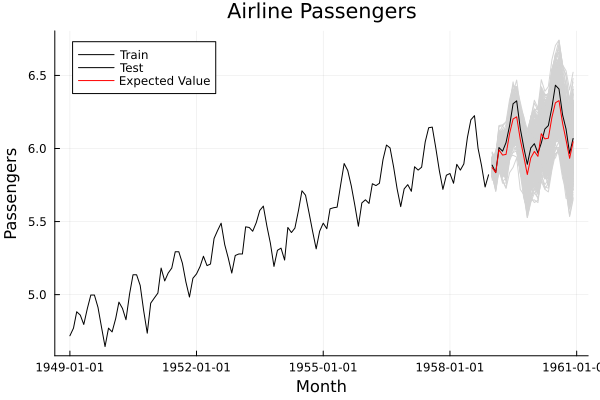

In [224]:
plot_forecast(airline_train, airline_test, vec(expected_value_airline), scenarios_airline[:, 1, :], "Airline Passengers", "month", "passengers", "Month", "Passengers")

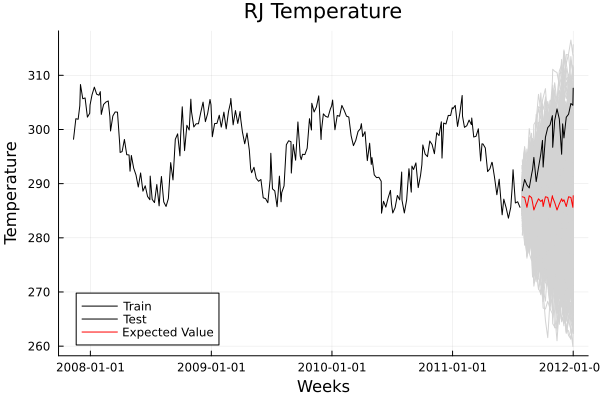

In [225]:
plot_forecast(rj_temp_train, rj_temp_test, vec(expected_value_rj), scenarios_rj[:, 1, :], "RJ Temperature", "Timestamp", "Values", "Weeks", "Temperature")